Problem Set 1: Simulating Customer Clicks Using a Bernoulli Random Variable
Problem Statement

An organization sends promotional emails. Historical data indicate that a customer clicks the link with probability:

$$ p = 0.30 $$

Define the random variable:

$$ X = \begin{cases} 1, & \text{if the customer clicks the link}\\ 0, & \text{if the customer does not click the link} \end{cases} $$

Therefore,

X∼Bernoulli(0.30)

Step 1: Identify the Random Variable
1. What does \(X=1\) represent?

Ans: \(X=1\) represents that the customer clicks the promotional link.

2. What does \(X=0\) represent?

Ans: \(X=0\) represents that the customer does not click the promotional link.

3. What are the possible values of \(X\)?

Ans:

$$ X \in \{0,1\} $$

Therefore, the random variable has only two possible outcomes:

0 → No click
1 → Click
4. Is \(X\) a discrete or continuous random variable?

Ans: \(X\) is a discrete random variable because it can take only a finite number of values, namely 0 and 1.

5. Which probability distribution is suitable for \(X\)?

Ans: The Bernoulli distribution is suitable because the experiment has exactly two possible outcomes: success (click) and failure (no click).

$$ X \sim Bernoulli(p) $$

where:

$$ p = P(X=1)=0.30 $$

and

P(X=0)=1−p=0.70

Step 2: Theoretical PMF

The probability mass function of a Bernoulli random variable is:

$$ P(X=x)=p^x(1-p)^{1-x}, \quad x\in\{0,1\} $$

For \(p=0.30\):

$$ P(X=0)=1-p=0.70 $$
P(X=1)=p=0.30

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Probability of a customer clicking
p = 0.30

# Possible outcomes
x = np.array([0, 1])

# Theoretical probabilities
theoretical_pmf = np.array([1 - p, p])

print("Theoretical PMF")
for outcome, probability in zip(x, theoretical_pmf):
    print(f"P(X={outcome}) = {probability:.2f}")

Theoretical PMF
P(X=0) = 0.70
P(X=1) = 0.30


Step 3: Generate Outcomes for 20 Customers

We use np.random.binomial(n=1, p=p) because one Bernoulli trial is performed for each customer.

In [4]:
sample_size = 20

samples = np.random.binomial(
    n=1,
    p=p,
    size=sample_size
)

print("Generated samples:")
print(samples)

print("Number of observations:", len(samples))

Generated samples:
[0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0]
Number of observations: 20


Questions

1. How many observations were generated?

20 observations were generated.

2. What does each zero represent?

Each 0 represents a customer who did not click.

3. What does each one represent?

Each 1 represents a customer who clicked.

4. Are the generated observations the same as the theoretical probabilities?

No. The generated observations are random, so their proportions will usually not be exactly 0.70 and 0.30. As the sample size increases, the empirical probabilities will generally get closer to the theoretical probabilities.

Step 4: Count Clicks and Non-Clicks

In [6]:
number_of_clicks = np.sum(samples == 1)

number_of_non_clicks = np.sum(samples == 0)

print("Number of clicks:", number_of_clicks)
print("Number of non-clicks:", number_of_non_clicks)
print("Total customers:", number_of_clicks + number_of_non_clicks)

Number of clicks: 5
Number of non-clicks: 15
Total customers: 20


Questions

How many customers clicked?

5 customers have clicked.

How many customers did not click?

15 customers have not clicked here.

Do the two counts add up to 20?

Yes, The Total Comes out to be 20.

Step 5: Calculate the Empirical PMF

The empirical probability is calculated as:

$$ P_{\text{empirical}}(X=x) = \frac{\text{Number of observations equal to }x} {\text{Total number of observations}} $$

In [7]:
empirical_pmf = np.array([
    np.mean(samples == 0),
    np.mean(samples == 1)
])

print("Empirical PMF")
for outcome, probability in zip(x, empirical_pmf):
    print(f"P(X={outcome}) = {probability:.4f}")

Empirical PMF
P(X=0) = 0.7500
P(X=1) = 0.2500


Step 6: Compare Empirical and Theoretical PMFs

In [8]:
comparison = pd.DataFrame({
    "Outcome": x,
    "Theoretical PMF": theoretical_pmf,
    "Empirical PMF": empirical_pmf
})

comparison

,Outcome,Theoretical PMF,Empirical PMF
0,0,0.7,0.75
1,1,0.3,0.25


Questions

1. Is the empirical probability of a click exactly 0.30?

It wont be usually, Like it is not a must of 0.30,here we generate 20 samples over here,if there is some form of random variation probability may vary from 0.30 here.

2. Which outcome has the larger probability?

The theoretical probability of no click (\(X=0\)) is larger:

$$ P(X=0)=0.70 $$

compared with:

$$ P(X=1)=0.30 $$

The empirical result may also show more zeros, but because of randomness this is not guaranteed in every simulation.

3. Why are the empirical and theoretical probabilities different?

The theoretical probability represents the true assumed probability of the model, while the empirical probability is calculated from a finite random sample. Random sampling causes variation between the two.

Step 7: Plot Empirical and Theoretical PMFs

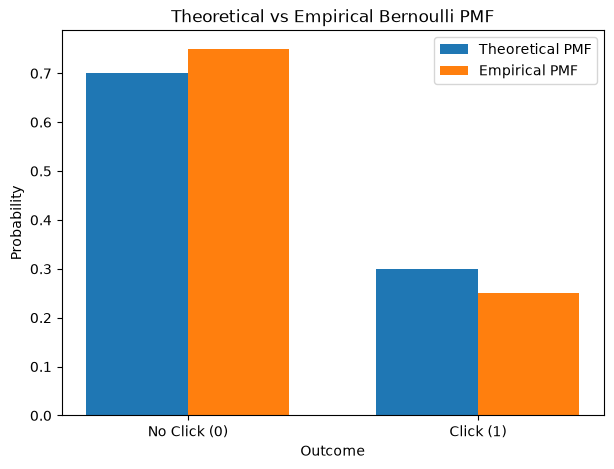

In [9]:
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(
    x - width/2,
    theoretical_pmf,
    width=width,
    label="Theoretical PMF"
)

plt.bar(
    x + width/2,
    empirical_pmf,
    width=width,
    label="Empirical PMF"
)

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Theoretical vs Empirical Bernoulli PMF")
plt.xticks(x, ["No Click (0)", "Click (1)"])
plt.legend()
plt.show()

Step 8: Calculate the Theoretical Expectation

For a Bernoulli random variable:

$$ E[X]=p $$

Therefore:

E[X]=0.30

In [10]:
theoretical_mean = p
print(f"Theoretical Mean: {theoretical_mean:.2f}")

Theoretical Mean: 0.30


Step 9: Calculate the Empirical ExpectationThe empirical expectation is simply the sample mean:$$\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$$

In [11]:
empirical_mean = np.mean(samples)

print("Empirical expectation:", empirical_mean)

Empirical expectation: 0.25


Step 10: Calculate the Theoretical Variance

For a Bernoulli random variable:

$$ Var(X)=p(1-p) $$

Therefore:

$$ Var(X)=0.30(1-0.30) $$ $$ Var(X)=0.30\times0.70=0.21 $$

In [12]:
theoretical_variance = p * (1 - p)

print("Theoretical variance:", theoretical_variance)

Theoretical variance: 0.21


Step 11: Calculate the Empirical Variance

In [13]:
empirical_variance = np.var(samples)
print("Empirical variance:", empirical_variance)

Empirical variance: 0.1875


Step 12: Final Result Table

In [14]:
absolute_difference_p0 = abs(theoretical_pmf[0] - empirical_pmf[0])
absolute_difference_p1 = abs(theoretical_pmf[1] - empirical_pmf[1])
absolute_difference_mean = abs(theoretical_mean - empirical_mean)
absolute_difference_variance = abs(
    theoretical_variance - empirical_variance
)

final_table = pd.DataFrame({
    "Measure": [
        "P(X=0)",
        "P(X=1)",
        "Expectation",
        "Variance"
    ],
    "Theoretical value": [
        theoretical_pmf[0],
        theoretical_pmf[1],
        theoretical_mean,
        theoretical_variance
    ],
    "Empirical value": [
        empirical_pmf[0],
        empirical_pmf[1],
        empirical_mean,
        empirical_variance
    ],
    "Absolute difference": [
        absolute_difference_p0,
        absolute_difference_p1,
        absolute_difference_mean,
        absolute_difference_variance
    ]
})

final_table

,Measure,Theoretical value,Empirical value,Absolute difference
0,P(X=0),0.70,0.7500,0.0500
1,P(X=1),0.30,0.2500,0.0500
2,Expectation,0.30,0.2500,0.0500
3,Variance,0.21,0.1875,0.0225


Step 13: Effect of Sample Size

We now repeat the Bernoulli experiment using:

n=10,100,1000,10000

In [17]:
sample_sizes = [10, 100, 1000, 10000]

results = []

for n in sample_sizes:

    samples_n = np.random.binomial(
        n=1,
        p=p,
        size=n
    )

    empirical_p0 = np.mean(samples_n == 0)
    empirical_p1 = np.mean(samples_n == 1)
    empirical_mean = np.mean(samples_n)
    empirical_variance = np.var(samples_n)

    results.append([
        n,
        empirical_p0,
        empirical_p1,
        empirical_mean,
        empirical_variance
    ])

sample_size_table = pd.DataFrame(
    results,
    columns=[
        "Sample size",
        "Empirical P(X=0)",
        "Empirical P(X=1)",
        "Empirical mean",
        "Empirical variance"
    ]
)

sample_size_table

,Sample size,Empirical P(X=0),Empirical P(X=1),Empirical mean,Empirical variance
0,10,0.7000,0.3000,0.3000,0.210000
1,100,0.7000,0.3000,0.3000,0.210000
2,1000,0.6730,0.3270,0.3270,0.220071
3,10000,0.7033,0.2967,0.2967,0.208669


Interpretation

As the sample size increases, the empirical values generally become closer to the theoretical values:

$$ P(X=0)=0.70 $$ $$ P(X=1)=0.30 $$ $$ E[X]=0.30 $$ $$ Var(X)=0.21 $$

This demonstrates the Law of Large Numbers: as the number of observations increases, empirical estimates tend to approach their theoretical probabilities and moments.